<h1>Monstro da Semana 3: Esqueleto</h1> 

<h4><i>Bruno Bini Camargo</i></h4>

<h2>Introdução</h2> 

No universo de Jogos Vorazes, saga de livros escrita pela estadunidense Suzanne Collins, acontece anual e obrigatoriamente um evento de mesmo nome, uma competição brutal criada pela Capital do país fictício Panem tanto para punir os 12 distritos por uma rebelião ocorrida no passado quanto para ser um lembrete permanente do poder dela [1].

Realizada em uma praça pública com a presença obrigatória de toda a população, o evento inicial dos Jogos, denominado Colheita [2], seleciona de maneira aleatória, por meio de urnas separadas por gênero, exatamente um jovem e uma jovem de cada distrito para lutar na arena dos Jogos Vorazes. A elegibilidade é restrita aos jovens de 12 a 18 anos. O sorteio utiliza um sistema cumulativo de fichas: ao completar 12 anos, o nome do candidato é inserido uma vez na urna; a cada ano subsequente, uma nova ficha é adicionada, totalizando sete inscrições aos 18 anos. 

No entanto, esse número pode aumentar drasticamente por meio das tésseras, um recurso de assistência que fornece uma cota anual de grãos e óleo para a sobrevivência de familiares em troca da inserção de mais fichas com o nome do jovem no sorteio. Essa troca desigual é amplamente utilizada em distritos pobres (como o 11 e o 12) e extremamente rara nos mais ricos (como o 1, 2 e 4).

Nessa atividade, vamos simular a Colheita desse universo, considerando o primeiro livro "Jogos Vorazes 1", em que a irmã da protagonista Katniss Everdeen, Primrose Everdeen, de 12 anos foi sorteada para a 74ª edição dos Jogos.

<h2>Desenvolvimento</h2> 

<h3>Definindo o grupo</h3>

Vamos nos focar no Distrito 12, o local de moradia dos protagonistas da saga. Segundo [3], à época dos 74º Jogos Vorazes, havia cerca de 8 mil habitantes nesse distrito. 

Precisamos nos atentar especificamente à quantidade de jovens (12 a 18 anos), pois apenas essa parcela da população pode ser sorteada. De acordo com [4], a porcentagem de jovens no mundo é de aproximadamente 16%. Assumindo que nessa sociedade fictícia essa porcentagem procede, a quantidade de jovens nesse distrito seria de 1280.

Katniss Everdeen, no primeiro livro, disse:

> "No Distrito 12, envelhecer é considerado uma conquista, pois a maioria das pessoas morre de fome muito antes disso."

Isso mostra que envelhecer é algo considerado muito difícil no distrito. Por isso, vamos assumir que, a cada 1 ano de idade que avança, diminui em 5% o número de pessoas, de forma que a distribuição dos jovens por idade se dá pela tabela abaixo:

In [1]:
import pandas as pd

df_jovens = pd.DataFrame({
    "Idade": [12, 13, 14, 15, 16, 17, 18],
    "Quantidade": [215, 204, 194, 183, 172, 161, 151],
    "Porcentagem do total (em %)": [16.7, 16, 15.2, 14.3, 13.4, 12.6, 11.8]
})

print(df_jovens.to_string(index=False))

 Idade  Quantidade  Porcentagem do total (em %)
    12         215                         16.7
    13         204                         16.0
    14         194                         15.2
    15         183                         14.3
    16         172                         13.4
    17         161                         12.6
    18         151                         11.8


<h3>Definindo as urnas</h3>

Pelas regras da Colheita, como anteriormente citado, o sistema de fichas é cumulativo, ou seja, é adicionada uma nova ficha à quantidade de fichas que o jovem já tinha no ano anterior. 

Como a idade mínima para participar da Colheita é 12 anos, primeiro é preciso determinar há quantos anos a pessoa  está participando do sorteio. Para uma idade i, esse tempo de participação é dado por n = i - 11. Assim, aos 12 anos temos n = 1, aos 13 anos n = 2, crescendo sucessivamente até os 18 anos, quando n = 7.

Em seguida, devemos analisar como as fichas se acumulam ano a ano. No seu primeiro ano (12 anos), o jovem recebe 1 ficha; no segundo ano (13 anos), ele recebe mais 2 fichas; no terceiro (14 anos), adicionam-se 3 fichas, e esse processo se repete a cada aniversário. Portanto, o total de fichas acumuladas por idade não é apenas o valor do ano atual, mas sim a soma de todas as entradas recebidas desde o início: 1 + 2 + 3 + ... + n.

Essa sequência de números consecutivos forma uma Progressão Aritmética (PA), cuja soma dos n primeiros termos é calculada pela fórmula $S_n = \frac{n(n + 1)}{2}$. Para adaptar essa equação à idade i da pessoa, substituímos n por (i - 11). Assim, o termo (n + 1) torna-se (i - 11 + 1), o que simplifica para (i - 10). Multiplicando esses dois termos e dividindo por 2, chega-se à expressão final

$$\text{Fichas Idade}(i) = \frac{(i - 11) \times (i - 10)}{2}$$

Esse resultado permite calcular o total de fichas acumuladas por qualquer idade. 

Mas, antes de passarmos essa fórmula para Python, devemos ter em mente que a quantidade de fichas também depende das tésseras, aquelas fichas adicionais para os jovens que quiserem cota anual de grãos e óleos. 

O distrito que estamos considerando é o 12, um local muito pobre. Mas seria exagero dizer que todas as famílias da região usam as tésseras, já que algumas são bem-sucedidas socioeconomicamente, a exemplo da família do prefeito. Assim, consideremos que 80% dos jovens do distrito 12 usam tésseras. 

Isso indica que 20% dos jovens terão a quantidade de fichas regida pela fórmula que já conseguimos antes. 
Já os outros 80% terão àquela quantidade de fichas uma soma de (i - 11) * t, sendo t a quantidade de tésseras por pessoa. 

Vamos assumir que cada família tem 4 membros (pai, mãe e dois filhos). Mas não é necessário que um irmão carregue a família nas costas, o fardo pode ser dividido entre os dois irmãos. Assim, a fórmula estimada para o cálculo da quantidade de fichas de um jovem em uma família pobre é:

$$\text{Fichas}_{\text{pobre}}(i) = \frac{(i - 11) \times (i - 10)}{2} + 2 \times (i - 11)$$

Vamos agora passar isso para uma função em Python:

In [2]:
def calcular_fichas(idade, e_pobre):

    anos_elegivel = idade - 11
    fichas_idade = (anos_elegivel * (anos_elegivel + 1)) // 2

    if e_pobre == True:
        tesseras = anos_elegivel * 2
    else:
        tesseras = 0

    return fichas_idade + tesseras

A Colheita seleciona obrigatoriamente um menino e uma menina. Para refletir isso no experimento, a população jovem de cada faixa etária é dividida igualmente em 50% do sexo feminino e 50% do sexo masculino, gerando duas urnas de sorteio independentes. Vamos agora criar uma função para definir as urnas:

In [3]:
def criar_urnas(df):
    urna_feminina = []
    urna_masculina = []

    for linha in df.itertuples():
        idade = int(linha.Idade)
        qtd_total = int(linha.Quantidade)

        qtd_meninas = qtd_total // 2
        qtd_meninos = qtd_total - qtd_meninas

        fichas_pobre = calcular_fichas(idade, e_pobre = True)
        fichas_rico = calcular_fichas(idade, e_pobre = False)

        pobres_fem = int(qtd_meninas * 0.8)
        ricas_fem = qtd_meninas - pobres_fem

        fichas_pobres_fem = pobres_fem * fichas_pobre
        fichas_ricas_fem = ricas_fem * fichas_rico

        urna_feminina.extend([(idade, True)] * fichas_pobres_fem)
        urna_feminina.extend([(idade, False)] * fichas_ricas_fem)

        pobres_masc = int(qtd_meninos * 0.8)
        ricos_masc = qtd_meninos - pobres_masc

        fichas_pobres_masc = pobres_masc * fichas_pobre
        fichas_ricos_masc = ricos_masc * fichas_rico

        urna_masculina.extend([(idade, True)] * fichas_pobres_masc)
        urna_masculina.extend([(idade, False)] * fichas_ricos_masc)

    return urna_feminina, urna_masculina

In [4]:
urna_fem, urna_masc = criar_urnas(df_jovens)

<h3>Simulando a Colheita</h3>

Agora que já temos a população elegível e as urnas com as fichas adequadas para as condições dos Jogos, vamos simular a Colheita:

In [5]:
import random

def simular_colheita(urna_menina, urna_menino):
    
    menina = random.choice(urna_menina)
    menino = random.choice(urna_menino)

    return menina, menino

(id_f, pob_f), (id_m, pob_m) = simular_colheita(urna_fem, urna_masc)

print(
    f"Menina: {id_f} anos, {'pobre' if pob_f else 'rico'}\n"
    f"Menino: {id_m} anos, {'pobre' if pob_m else 'rico'}"
)

Menina: 18 anos, pobre
Menino: 18 anos, pobre


A função acima expressa um sorteio. Agora vamos simular uma década de Colheitas, considerando as mesmas condições anteriores:

In [6]:
def colheita_decada():
    resultado_decada = []
    for _ in range(10):
        resultado_decada.append(simular_colheita(urna_fem, urna_masc))
    return resultado_decada

In [7]:
def imprimir_decada(decada):
    for ano, ((id_f, pob_f), (id_m, pob_m)) in enumerate(decada, start=1):
        status_f = "pobre" if pob_f else "rico"
        status_m = "pobre" if pob_m else "rico"

        print(f"{ano}º ano:")
        print(f"Menina: {id_f} anos, {status_f}")
        print(f"Menino: {id_m} anos, {status_m}\n")

decada_sorteada = colheita_decada()
imprimir_decada(decada_sorteada)

1º ano:
Menina: 15 anos, rico
Menino: 18 anos, rico

2º ano:
Menina: 14 anos, pobre
Menino: 18 anos, pobre

3º ano:
Menina: 17 anos, pobre
Menino: 16 anos, pobre

4º ano:
Menina: 14 anos, pobre
Menino: 15 anos, pobre

5º ano:
Menina: 16 anos, pobre
Menino: 18 anos, pobre

6º ano:
Menina: 18 anos, pobre
Menino: 17 anos, pobre

7º ano:
Menina: 17 anos, pobre
Menino: 18 anos, pobre

8º ano:
Menina: 17 anos, pobre
Menino: 13 anos, pobre

9º ano:
Menina: 17 anos, pobre
Menino: 15 anos, rico

10º ano:
Menina: 15 anos, pobre
Menino: 18 anos, rico



Constatamos que estatisticamente é mais provável que seja sorteado um jovem pobre do que um rico, uma vez que ele apresenta maior quantidade de fichas. Também verificamos que, quanto mais velho, mais provável de ser sorteado, pelo mesmo motivo, mesmo esses representando um menor percentual da parcela de jovens.

Vamos olhar para essa década e verificar quantas vezes uma menina pobre de 12 anos (nosso evento) será sorteada:

In [8]:
decada = colheita_decada()

total_sorteios = sum(1 for (id_f, pob_f), _ in decada if id_f == 12 and pob_f)

print(
    f"Na década analisada, a menina pobre de 12 anos foi sorteada {total_sorteios} vez(es)."
)

Na década analisada, a menina pobre de 12 anos foi sorteada 2 vez(es).


Repetindo essa célula acima consecutivas vezes, percebemos que a probabilidade de sorteio nessas condições é bem pequena, sendo na maior parte das vezes 0.

Agora, com o objetivo de melhorar nossa confiança no resultado, vamos repetir essa simulação de uma década 100 mil vezes:

In [9]:
def executar_experimento(df, num_simulacoes):
    urna_fem, urna_masc = criar_urnas(df)
    resultado_global = []

    for _ in range(num_simulacoes):
        decada = colheita_decada()

        contagem_decada = 0
        for (idade_fem, e_pobre_fem), (idade_masc, e_pobre_masc) in decada:
            if (idade_fem == 12) and (e_pobre_fem is True):
                contagem_decada += 1

        resultado_global.append(contagem_decada)

    return resultado_global

In [10]:
import statistics as st

NUM_SIMULACOES = 100000
resultado = executar_experimento(df_jovens, NUM_SIMULACOES)

media_ocorrencias = st.mean(resultado)
total_sucessos = sum(resultado)

print(
    f"Em média, uma menina pobre de 12 anos é sorteada {media_ocorrencias:.2f} vezes por década."
)

print(
    f"Total de sorteios do evento: {total_sucessos} em {NUM_SIMULACOES} décadas simuladas."
)

Em média, uma menina pobre de 12 anos é sorteada 0.24 vezes por década.
Total de sorteios do evento: 23684 em 100000 décadas simuladas.


Essa simulação comprova a baixa probabilidade de sorteio para as condições estipuladas.

Agora vamos representar visualmente em um histograma a simulação acima:

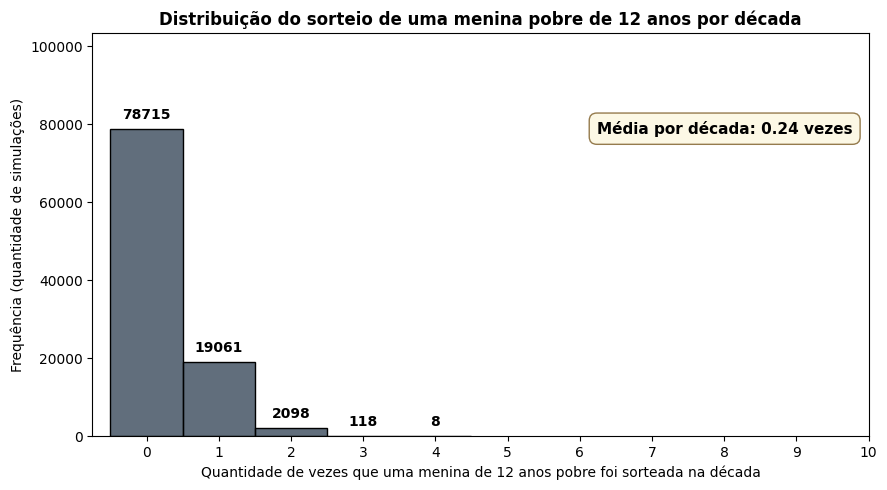

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

resultado = executar_experimento(df_jovens, 100000)
media = st.mean(resultado)

plt.figure(figsize=(9, 5))
eixo = sns.histplot(resultado, discrete=True, color="#2c3e50")

for p in eixo.patches:
    altura = int(p.get_height())
    if altura > 0:
        eixo.annotate(
            f"{altura}",
            (p.get_x() + p.get_width() / 2.0, altura),
            ha="center",
            va="bottom",
            xytext=(0, 5),
            textcoords="offset points",
            fontweight="bold",
        )

eixo.set_xticks(range(11))
eixo.set_xlabel("Quantidade de vezes que uma menina de 12 anos pobre foi sorteada na década")
eixo.set_ylabel("Frequência (quantidade de simulações)")
eixo.set_title(
    "Distribuição do sorteio de uma menina pobre de 12 anos por década",
    fontsize=12,
    fontweight="bold",
)

eixo.set_ylim(0, max(eixo.get_yticks()) * 1.15)

plt.text(
    0.65,
    0.75,
    f"Média por década: {media:.2f} vezes",
    transform=eixo.transAxes,
    fontsize=11,
    fontweight="bold",
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="#fcf8e3",
        edgecolor="#8a6d3b",
        alpha=0.9,
    ),
)

plt.tight_layout()
plt.show()

Para uma menina pobre de 12 anos, o histograma nos mostra que, em 100 mil simulações de uma década, o evento dominante foi o não sorteio, o secundário foi 1 sorteio e o residual foi de 2 a 4 sorteios. 

Isso constata visualmente que é muito pequena a probabilidade de uma menina pobre de 12 anos ser sorteada na Colheita.

<h2>Conclusão</h2> 

Ao simular a Colheita, testamos a probabilidade de uma menina pobre de 12 anos ser sorteada. Percebemos, após 100 mil simulações para uma década, que a média desse sorteio é de 0.23 a 0.24 vezes. 

Ao rodar 100 mil simulações, verificamos que o experimento demonstra que o acúmulo de dados faz a média convergir para um resultado mais confiável.

Portanto, observamos que, embora o evento do sorteio da irmã da protagonista no primeiro livro apresente uma pequena probabilidade, ele não é impossível. 

<h3>Interação com a IA</h3>

A inteligência artificial generativa foi utilizada ao longo do projeto como ferramenta de apoio na parte da programação, resolvendo dúvidas de sintaxe e realizando correções de erros de código (*debugging*).

<h2>Referências bibliográficas</h2>

1 - Hunger Games (event). Disponível em: <https://thehungergames.fandom.com/wiki/Hunger_Games_(event)>. Acesso em: 26 ago. 2026.

2 - Reaping. Disponível em: <https://thehungergames.fandom.com/wiki/Reaping>. Acesso em: 26 ago. 2026.

3 - District 12. Disponível em: <https://thehungergames.fandom.com/wiki/District_12>. Acesso em: 26 ago.. 2026.

4 - Juventude. Disponível em: <https://unric.org/pt/juventude/>. Acesso em: 26 ago. 2026.